# 🔍 Practical 02 - Advanced BFS & DFS Maze Solver

This notebook solves a custom maze layout using **Breadth-First Search (BFS)** and **Depth-First Search (DFS)**, plotting the explored zones and final paths.

### 1. Imports and Maze Definitions

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import deque

# Maze: 0 = path, 1 = wall
maze = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)
directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def is_valid(pos, visited):
    x, y = pos
    return (0 <= x < len(maze) and
            0 <= y < len(maze[0]) and
            maze[x][y] == 0 and
            pos not in visited)

### 2. Breadth-First Search (BFS)

Finds the shortest path from start to goal.

In [2]:
def bfs(start, goal):
    queue = deque([[start]])
    visited = set()
    explored = []   # For visualization
    while queue:
        path = queue.popleft()
        x, y = path[-1]
        explored.append((x, y))
        if (x, y) == goal:
            return path, explored
        if (x, y) in visited:
            continue
        visited.add((x, y))
        for dx, dy in directions:
            next_pos = (x + dx, y + dy)
            if is_valid(next_pos, visited):
                queue.append(path + [next_pos])
    return None, explored

### 3. Depth-First Search (DFS)

Explores as far as possible along each branch before backtracking.

In [3]:
def dfs(start, goal):
    stack = [[start]]
    visited = set()
    explored = []   # For visualization
    while stack:
        path = stack.pop()
        x, y = path[-1]
        explored.append((x, y))
        if (x, y) == goal:
            return path, explored
        if (x, y) in visited:
            continue
        visited.add((x, y))
        for dx, dy in directions:
            next_pos = (x + dx, y + dy)
            if is_valid(next_pos, visited):
                stack.append(path + [next_pos])
    return None, explored

### 4. Execute Algorithms

In [4]:
bfs_path, bfs_explored = bfs(start, goal)
dfs_path, dfs_explored = dfs(start, goal)

print("BFS Path:", bfs_path)
print("DFS Path:", dfs_path)

BFS Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]
DFS Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]


### 5. Visualize Results

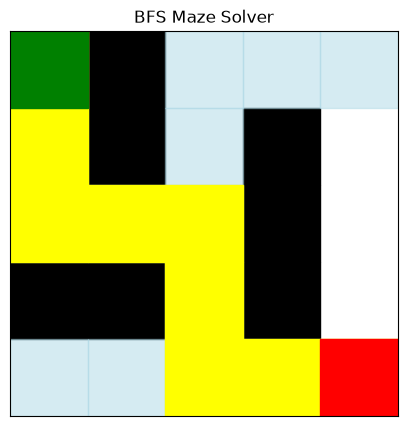

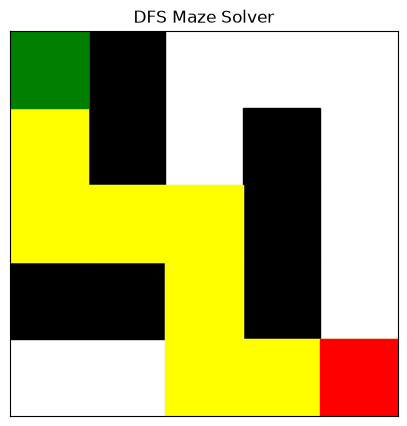

In [5]:
def visualize(maze, path, explored, title=""):
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)

    # Draw maze walls
    for i in range(len(maze)):
        for j in range(len(maze[0])):
            if maze[i][j] == 1:
                ax.add_patch(plt.Rectangle((j, len(maze)-i-1), 1, 1, color="black"))

    # Draw explored nodes
    for (x, y) in explored:
        ax.add_patch(plt.Rectangle((y, len(maze)-x-1), 1, 1, color="lightblue", alpha=0.5))

    # Draw final path
    if path:
        for (x, y) in path:
            ax.add_patch(plt.Rectangle((y, len(maze)-x-1), 1, 1, color="yellow"))

    # Start & Goal nodes
    sx, sy = start
    gx, gy = goal
    ax.add_patch(plt.Rectangle((sy, len(maze)-sx-1), 1, 1, color="green"))
    ax.add_patch(plt.Rectangle((gy, len(maze)-gx-1), 1, 1, color="red"))

    ax.set_xlim(0, len(maze[0]))
    ax.set_ylim(0, len(maze))
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

visualize(maze, bfs_path, bfs_explored, "BFS Maze Solver")
visualize(maze, dfs_path, dfs_explored, "DFS Maze Solver")